In [1]:
import os
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
import numpy as np
from sklearn.metrics import precision_recall_curve
import random
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError



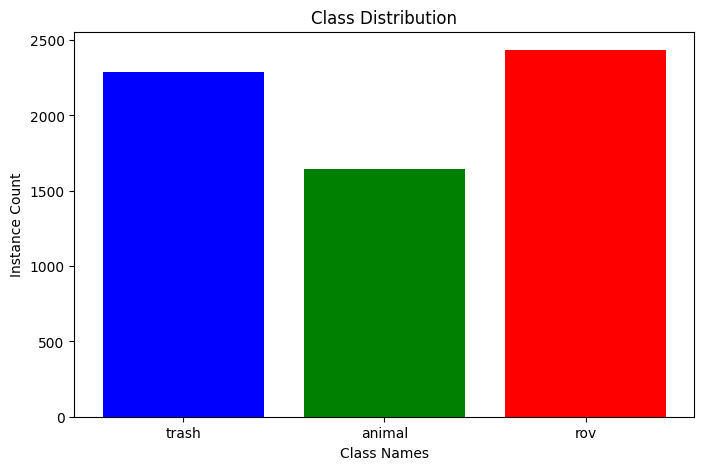

In [2]:
import yaml
import os
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
from collections import Counter

# Load YAML file
yaml_path = "D:/C_V8/data.yaml"
with open(yaml_path, 'r') as file:
    data = yaml.safe_load(file)

train_images_path = data['train']
train_labels_path = train_images_path.replace("images", "labels")  # Assuming labels are in a parallel folder

# 1. Class Distribution Visualization
class_counts = Counter()
for label_file in os.listdir(train_labels_path):
    with open(os.path.join(train_labels_path, label_file), "r") as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

class_names = data['names']
class_counts_named = {class_names[k]: v for k, v in class_counts.items()}

plt.figure(figsize=(8,5))
plt.bar(class_counts_named.keys(), class_counts_named.values(), color=['blue', 'green', 'red', 'purple'])
plt.xlabel("Class Names")
plt.ylabel("Instance Count")
plt.title("Class Distribution")
plt.show()


Sample image sizes: [[640 640]
 [640 640]
 [640 640]
 [640 640]
 [640 640]]


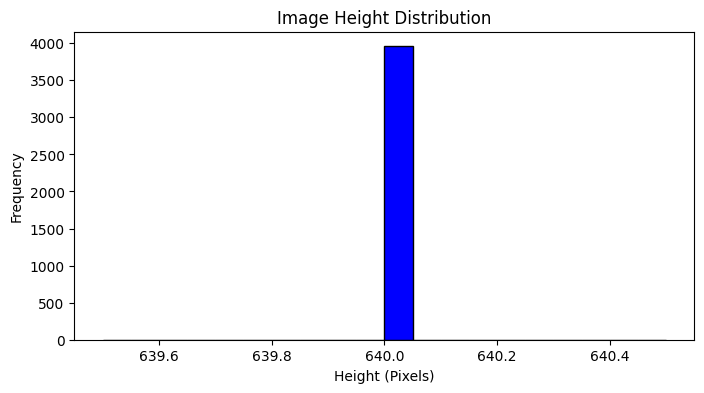

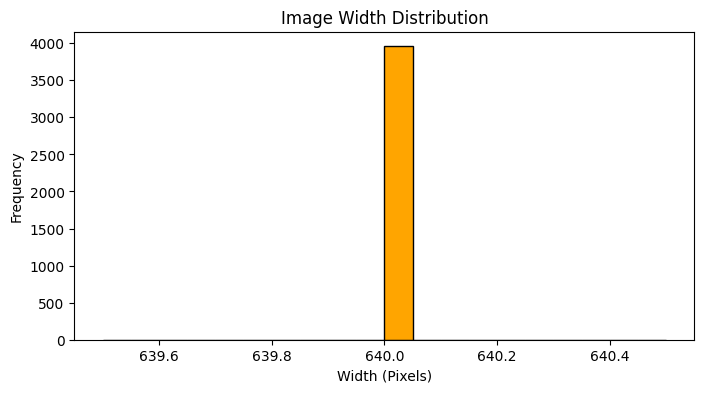

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_sizes = []

# Load images and get dimensions
for img_name in os.listdir(train_images_path):
    img_path = os.path.join(train_images_path, img_name)
    img = cv2.imread(img_path)

    if img is not None:
        height, width = img.shape[:2]
        image_sizes.append((height, width))

# Convert to NumPy array
if image_sizes:
    image_sizes = np.array(image_sizes)

    # Debugging: Print sample sizes
    print("Sample image sizes:", image_sizes[:5])

    # Plot Height Distribution
    plt.figure(figsize=(8, 4))
    plt.hist(image_sizes[:, 0], bins=20, color='blue', edgecolor='black')
    plt.xlabel("Height (Pixels)")
    plt.ylabel("Frequency")
    plt.title("Image Height Distribution")
    plt.show()

    # Plot Width Distribution
    plt.figure(figsize=(8, 4))
    plt.hist(image_sizes[:, 1], bins=20, color='orange', edgecolor='black')
    plt.xlabel("Width (Pixels)")
    plt.ylabel("Frequency")
    plt.title("Image Width Distribution")
    plt.show()
    
else:
    print("No images found or read correctly.")


In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # Choose 'n', 's', 'm', 'l'

results = model.train(
    data="D:/C_V8/data.yaml",
    epochs=100,
    batch=32,
    imgsz=640,
    optimizer="AdamW",
    lr0=0.0001,
    lrf=0.01,
    weight_decay=0.0005,
    momentum=0.937,
    cos_lr=True,
    warmup_epochs=3,
    augment=True,
    device="cuda",
    patience=10,
    verbose=True
)



100%|██████████| 6.25M/6.25M [00:00<00:00, 12.7MB/s]


New https://pypi.org/project/ultralytics/8.3.84 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.80  Python-3.9.21 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=D:/C_V8/data.yaml, epochs=100, time=None, patience=10, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, 

100%|██████████| 5.35M/5.35M [00:00<00:00, 12.0MB/s]


AMP: checks passed 


train: Scanning D:\C_V8\train\labels.cache... 3957 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3957/3957 [00:00<?, ?it/s]

...

     95/100      3.82G     0.7239     0.5584      1.001         32        640: 100%|██████████| 124/124 [00:28<00:00,  4.38it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:06<00:00,  2.92it/s]

                   all       1133       1819       0.89      0.837      0.913      0.704
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 85, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



95 epochs completed in 1.122 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 6.3MB
Optimizer stripped from runs\detect\train\weights\best.pt, 6.3MB

Validating runs\detect\train\weights\best.pt...
Ultralytics 8.3.80  Python-3.9.21 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:10<00:00,  1.69it/s]


                   all       1133       1819      0.889      0.845      0.912       0.71
                animal        287        458      0.872      0.725      0.832      0.558
                   rov        555        711      0.896      0.897      0.954      0.832
                 trash        585        650      0.899      0.913       0.95      0.739
Speed: 0.2ms preprocess, 4.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs\detect\train


In [5]:
import yaml

def get_class_info(filepath):
    try:
        with open(filepath, "r") as file:
            data = yaml.safe_load(file)
            if data and "names" in data and isinstance(data["names"], list):
                class_info = []
                for i, name in enumerate(data["names"]):  # Use enumerate to get index (ID)
                    class_info.append({"name": name, "id": i})
                return class_info
            else:
                return None
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return None
    except yaml.YAMLError as e:
        print(f"Error: YAML parsing error: {e}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None

filepath = "D:/C_V8/data.yaml"
class_data = get_class_info(filepath)

if class_data:
    for item in class_data:
        print(f"Class: {item['name']}, ID: {item['id']}")
else:
    print("No class information found or error occurred.")

Class: animal, ID: 0
Class: rov, ID: 1
Class: trash, ID: 2


In [6]:
# Save the trained model
model.save("yolov8n.pt")

In [7]:
model = YOLO("C:/Users/saman/OneDrive/Desktop/Research/YoloV8_C3/0.0001/V8n/yolov8n.pt")

In [11]:
import os
import random
from ultralytics import YOLO  # Make sure to import the YOLO class

# Load the trained model
trained_model = YOLO("C:/Users/saman/OneDrive/Desktop/Research/YoloV8_C3/0.0001/V8n/runs/detect/train/weights/best.pt"
)
# Define the test directory
test_dir = "D:/C_V8/test/images"

# Get a list of all images in the test directory
test_images = [os.path.join(test_dir, img) for img in os.listdir(test_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]

# Select 10 random images
random_images = random.sample(test_images, min(10, len(test_images)))  # Ensure we don't exceed the number of available images

# Process the selected images
for img_path in random_images:
    results = trained_model.predict(source=img_path, save=True, conf=0.25)

    # Print results for each image
    for result in results:
        print(f"Image: {img_path}, Class: {result.boxes.cls}, Confidence: {result.boxes.conf}")


image 1/1 D:\C_V8\test\images\vid_000333_frame0000010_jpg.rf.3bedc860359ea37eb9942ef4f9101e3c.jpg: 640x640 1 rov, 8.2ms
Speed: 2.5ms preprocess, 8.2ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs\detect\predict4
Image: D:/C_V8/test/images\vid_000333_frame0000010_jpg.rf.3bedc860359ea37eb9942ef4f9101e3c.jpg, Class: tensor([1.], device='cuda:0'), Confidence: tensor([0.8756], device='cuda:0')

image 1/1 D:\C_V8\test\images\vid_000539_frame0000047_jpg.rf.26a59a63f0bb80b4aa40a24cdb1f06cd.jpg: 640x640 1 animal, 1 trash, 8.2ms
Speed: 2.7ms preprocess, 8.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs\detect\predict4
Image: D:/C_V8/test/images\vid_000539_frame0000047_jpg.rf.26a59a63f0bb80b4aa40a24cdb1f06cd.jpg, Class: tensor([2., 0.], device='cuda:0'), Confidence: tensor([0.9539, 0.5612], device='cuda:0')

image 1/1 D:\C_V8\test\images\vid_000158_frame0000110_jpg.rf.01ff567e4fe74f94507b99151c263f97.jpg: 640x64

In [12]:
import os
from ultralytics import YOLO

# Load the trained model
trained_model = YOLO("C:/Users/saman/OneDrive/Desktop/Research/YoloV8_C3/0.0001/V8n/runs/detect/train/weights/best.pt")

# Define the path to the specific image you want to predict
image_path = "D:/C_V8/test/images/vid_000434_frame0000021_jpg.rf.3d67289386c659e2620602397b9060b7.jpg"  # Replace with the actual path
# Check if the image file exists
if not os.path.exists(image_path):
    print(f"Error: Image file not found at {image_path}")
    exit()  # Or handle the error as needed

try:
    # Perform prediction on the single image
    results = trained_model.predict(source=image_path, save=True, conf=0.25)  # save=True will save the image with bounding boxes

    # Process the results
    for result in results:  # Iterate through results (even if it's just one image, results is a list)
        print(f"Image: {image_path}")  # Print image path once per image
        boxes = result.boxes  # Boxes object for detected objects

        if boxes:  # Check if any objects were detected
            for box in boxes:  # Iterate through detected objects
                xyxy = box.xyxy[0].tolist()  # Bounding box coordinates (x1, y1, x2, y2) - convert to list
                xywh = box.xywh[0].tolist()  # Bounding box coordinates (x_center, y_center, width, height) - convert to list
                cls = int(box.cls[0])  # Class index - convert to int
                conf = float(box.conf[0])  # Confidence score - convert to float

                print(f"  - Box (xyxy): {xyxy}, Box (xywh): {xywh}, Class: {cls}, Confidence: {conf}")
        else:
            print("  No objects detected in this image.")  # Informative message if no detections

except Exception as e:
    print(f"An error occurred during prediction: {e}")


image 1/1 D:\C_V8\test\images\vid_000434_frame0000021_jpg.rf.3d67289386c659e2620602397b9060b7.jpg: 640x640 5 animals, 23.9ms
Speed: 2.9ms preprocess, 23.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs\detect\predict5
Image: D:/C_V8/test/images/vid_000434_frame0000021_jpg.rf.3d67289386c659e2620602397b9060b7.jpg
  - Box (xyxy): [167.8878173828125, 275.6483154296875, 388.794921875, 365.4384765625], Box (xywh): [278.34136962890625, 320.54339599609375, 220.9071044921875, 89.7901611328125], Class: 0, Confidence: 0.9676952958106995
  - Box (xyxy): [144.95193481445312, 376.7856750488281, 404.6460266113281, 499.9763488769531], Box (xywh): [274.7989807128906, 438.3810119628906, 259.694091796875, 123.190673828125], Class: 0, Confidence: 0.9646732807159424
  - Box (xyxy): [85.04554748535156, 153.53366088867188, 145.32994079589844, 258.1771545410156], Box (xywh): [115.187744140625, 205.85540771484375, 60.284393310546875, 104.64349365234375], Class: 0, Con

In [13]:
import os
from ultralytics import YOLO

# Load the trained model
trained_model = YOLO("C:/Users/saman/OneDrive/Desktop/Research/YoloV8_C3/0.0001/V8n/runs/detect/train/weights/best.pt")

# Define the path to the specific image you want to predict
image_path = "D:/C_V8/test/images/vid_000444_frame0000108_jpg.rf.b3edd8abfd44341863aa9c53aa95e356.jpg"  # Replace with the actual path
# Check if the image file exists
if not os.path.exists(image_path):
    print(f"Error: Image file not found at {image_path}")
    exit()  # Or handle the error as needed

try:
    # Perform prediction on the single image
    results = trained_model.predict(source=image_path, save=True, conf=0.25)  # save=True will save the image with bounding boxes

    # Process the results
    for result in results:  # Iterate through results (even if it's just one image, results is a list)
        print(f"Image: {image_path}")  # Print image path once per image
        boxes = result.boxes  # Boxes object for detected objects

        if boxes:  # Check if any objects were detected
            for box in boxes:  # Iterate through detected objects
                xyxy = box.xyxy[0].tolist()  # Bounding box coordinates (x1, y1, x2, y2) - convert to list
                xywh = box.xywh[0].tolist()  # Bounding box coordinates (x_center, y_center, width, height) - convert to list
                cls = int(box.cls[0])  # Class index - convert to int
                conf = float(box.conf[0])  # Confidence score - convert to float

                print(f"  - Box (xyxy): {xyxy}, Box (xywh): {xywh}, Class: {cls}, Confidence: {conf}")
        else:
            print("  No objects detected in this image.")  # Informative message if no detections

except Exception as e:
    print(f"An error occurred during prediction: {e}")


image 1/1 D:\C_V8\test\images\vid_000444_frame0000108_jpg.rf.b3edd8abfd44341863aa9c53aa95e356.jpg: 640x640 3 animals, 23.9ms
Speed: 3.4ms preprocess, 23.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs\detect\predict6
Image: D:/C_V8/test/images/vid_000444_frame0000108_jpg.rf.b3edd8abfd44341863aa9c53aa95e356.jpg
  - Box (xyxy): [335.2410888671875, 239.47634887695312, 455.58538818359375, 448.6570739746094], Box (xywh): [395.4132385253906, 344.06671142578125, 120.34429931640625, 209.18072509765625], Class: 0, Confidence: 0.956913411617279
  - Box (xyxy): [96.79923248291016, 192.1468048095703, 219.19186401367188, 353.99261474609375], Box (xywh): [157.99554443359375, 273.0697021484375, 122.39263153076172, 161.84580993652344], Class: 0, Confidence: 0.8795339465141296
  - Box (xyxy): [509.5433349609375, 203.74029541015625, 635.9080810546875, 332.30560302734375], Box (xywh): [572.7257080078125, 268.02294921875, 126.36474609375, 128.5653076171875], Cla

In [14]:

import os
from ultralytics import YOLO

# Load the trained model
trained_model = YOLO("C:/Users/saman/OneDrive/Desktop/Research/YoloV8_C3/0.0001/V8n/runs/detect/train/weights/best.pt")

# Define the path to the specific image you want to predict
image_path = "D:/C_V8/test/images/vid_000532_frame0000160_jpg.rf.9ffce0025fcac8c4e5ff992233ae1261.jpg"  # Replace with the actual path
# Check if the image file exists
if not os.path.exists(image_path):
    print(f"Error: Image file not found at {image_path}")
    exit()  # Or handle the error as needed

try:
    # Perform prediction on the single image
    results = trained_model.predict(source=image_path, save=True, conf=0.25)  # save=True will save the image with bounding boxes

    # Process the results
    for result in results:  # Iterate through results (even if it's just one image, results is a list)
        print(f"Image: {image_path}")  # Print image path once per image
        boxes = result.boxes  # Boxes object for detected objects

        if boxes:  # Check if any objects were detected
            for box in boxes:  # Iterate through detected objects
                xyxy = box.xyxy[0].tolist()  # Bounding box coordinates (x1, y1, x2, y2) - convert to list
                xywh = box.xywh[0].tolist()  # Bounding box coordinates (x_center, y_center, width, height) - convert to list
                cls = int(box.cls[0])  # Class index - convert to int
                conf = float(box.conf[0])  # Confidence score - convert to float

                print(f"  - Box (xyxy): {xyxy}, Box (xywh): {xywh}, Class: {cls}, Confidence: {conf}")
        else:
            print("  No objects detected in this image.")  # Informative message if no detections

except Exception as e:
    print(f"An error occurred during prediction: {e}")


image 1/1 D:\C_V8\test\images\vid_000532_frame0000160_jpg.rf.9ffce0025fcac8c4e5ff992233ae1261.jpg: 640x640 1 animal, 1 trash, 24.1ms
Speed: 3.3ms preprocess, 24.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs\detect\predict7
Image: D:/C_V8/test/images/vid_000532_frame0000160_jpg.rf.9ffce0025fcac8c4e5ff992233ae1261.jpg
  - Box (xyxy): [114.2441177368164, 369.78668212890625, 169.51260375976562, 429.64117431640625], Box (xywh): [141.87835693359375, 399.71392822265625, 55.26848602294922, 59.8544921875], Class: 0, Confidence: 0.9033532738685608
  - Box (xyxy): [82.71531677246094, 424.31634521484375, 128.38330078125, 501.08160400390625], Box (xywh): [105.54930877685547, 462.698974609375, 45.66798400878906, 76.7652587890625], Class: 2, Confidence: 0.899741530418396


In [15]:

import os
from ultralytics import YOLO

# Load the trained model
trained_model = YOLO("C:/Users/saman/OneDrive/Desktop/Research/YoloV8_C3/0.0001/V8n/runs/detect/train/weights/best.pt")

# Define the path to the specific image you want to predict
image_path = "D:/C_V8/test/images/vid_000553_frame0000028_jpg.rf.f2200b6795689fc919d12fa961fae484.jpg"  # Replace with the actual path
# Check if the image file exists
if not os.path.exists(image_path):
    print(f"Error: Image file not found at {image_path}")
    exit()  # Or handle the error as needed

try:
    # Perform prediction on the single image
    results = trained_model.predict(source=image_path, save=True, conf=0.25)  # save=True will save the image with bounding boxes

    # Process the results
    for result in results:  # Iterate through results (even if it's just one image, results is a list)
        print(f"Image: {image_path}")  # Print image path once per image
        boxes = result.boxes  # Boxes object for detected objects

        if boxes:  # Check if any objects were detected
            for box in boxes:  # Iterate through detected objects
                xyxy = box.xyxy[0].tolist()  # Bounding box coordinates (x1, y1, x2, y2) - convert to list
                xywh = box.xywh[0].tolist()  # Bounding box coordinates (x_center, y_center, width, height) - convert to list
                cls = int(box.cls[0])  # Class index - convert to int
                conf = float(box.conf[0])  # Confidence score - convert to float

                print(f"  - Box (xyxy): {xyxy}, Box (xywh): {xywh}, Class: {cls}, Confidence: {conf}")
        else:
            print("  No objects detected in this image.")  # Informative message if no detections

except Exception as e:
    print(f"An error occurred during prediction: {e}")


image 1/1 D:\C_V8\test\images\vid_000553_frame0000028_jpg.rf.f2200b6795689fc919d12fa961fae484.jpg: 640x640 1 trash, 24.2ms
Speed: 6.5ms preprocess, 24.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs\detect\predict8
Image: D:/C_V8/test/images/vid_000553_frame0000028_jpg.rf.f2200b6795689fc919d12fa961fae484.jpg
  - Box (xyxy): [162.08065795898438, 413.34368896484375, 315.09918212890625, 499.81671142578125], Box (xywh): [238.5899200439453, 456.5802001953125, 153.01852416992188, 86.4730224609375], Class: 2, Confidence: 0.931538462638855


In [16]:
import pandas as pd

# Load the results.csv file
file_path = "C:/Users/saman/OneDrive/Desktop/Research/YoloV8_C3/0.0001/V8n/runs/detect/train/results.csv"
df = pd.read_csv(file_path)

# Display the first few rows to understand the structure
df.head()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,166.027,1.33252,2.70633,1.34240,0.81519,0.14534,0.17343,0.09530,1.49338,3.17914,1.58612,0.066969,0.000033,0.000033
1,2,275.674,1.22275,1.98886,1.28342,0.51470,0.44274,0.44825,0.30716,1.10755,1.80226,1.25354,0.033668,0.000066,0.000066
2,3,377.358,1.15715,1.79680,1.25178,0.55229,0.52563,0.53397,0.37359,1.03394,1.48035,1.17000,0.000368,0.000100,0.000100
3,4,469.954,1.11369,1.63058,1.21880,0.62987,0.54299,0.59720,0.42530,0.98938,1.35721,1.13941,0.000100,0.000100,0.000100
4,5,574.537,1.09698,1.52750,1.20483,0.67072,0.58682,0.63848,0.45102,0.98381,1.28258,1.13719,0.000100,0.000100,0.000100


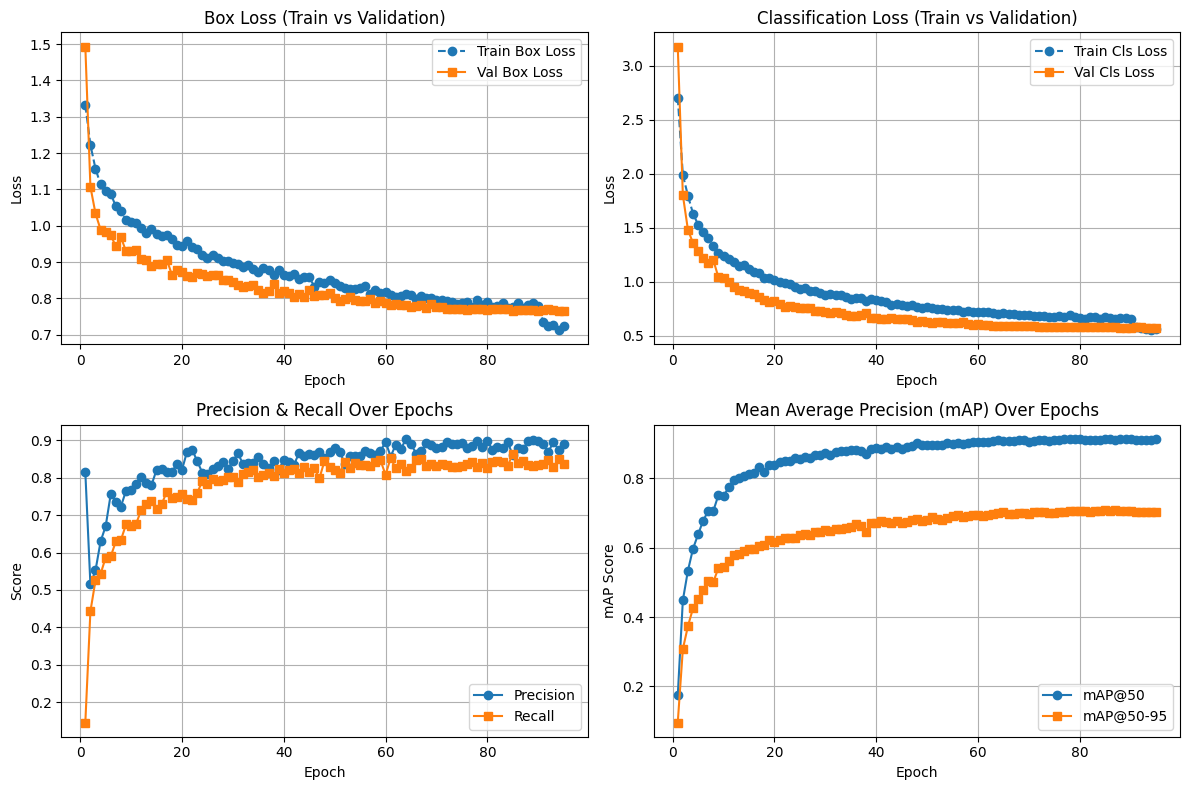

In [17]:
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(12, 8))

# Loss Curves (Training & Validation)
plt.subplot(2, 2, 1)
plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss", linestyle="--", marker="o")
plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="-", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Box Loss (Train vs Validation)")
plt.legend()
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss", linestyle="--", marker="o")
plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="-", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classification Loss (Train vs Validation)")
plt.legend()
plt.grid()

# Precision & Recall Over Epochs
plt.subplot(2, 2, 3)
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision", linestyle="-", marker="o")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall", linestyle="-", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision & Recall Over Epochs")
plt.legend()
plt.grid()

# mAP Scores Over Epochs
plt.subplot(2, 2, 4)
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@50", linestyle="-", marker="o")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@50-95", linestyle="-", marker="s")
plt.xlabel("Epoch")
plt.ylabel("mAP Score")
plt.title("Mean Average Precision (mAP) Over Epochs")
plt.legend()
plt.grid()

# Show all plots
plt.tight_layout()
plt.show()
